In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)

al = pd.read_parquet("../data/processed/escolas_alagoas.parquet")
df = pd.read_parquet("../data/processed/escolas_limpo.parquet")

infra = ["IN_INTERNET","IN_BIBLIOTECA","IN_LABORATORIO_INFORMATICA",
         "IN_LABORATORIO_CIENCIAS","IN_QUADRA_ESPORTES"]
for col in infra:
    al[col] = pd.to_numeric(al[col], errors="coerce")
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Pronto")

c:\Users\allan\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


Pronto!


Correlação entre porcentagem de negros e insfraestrutura

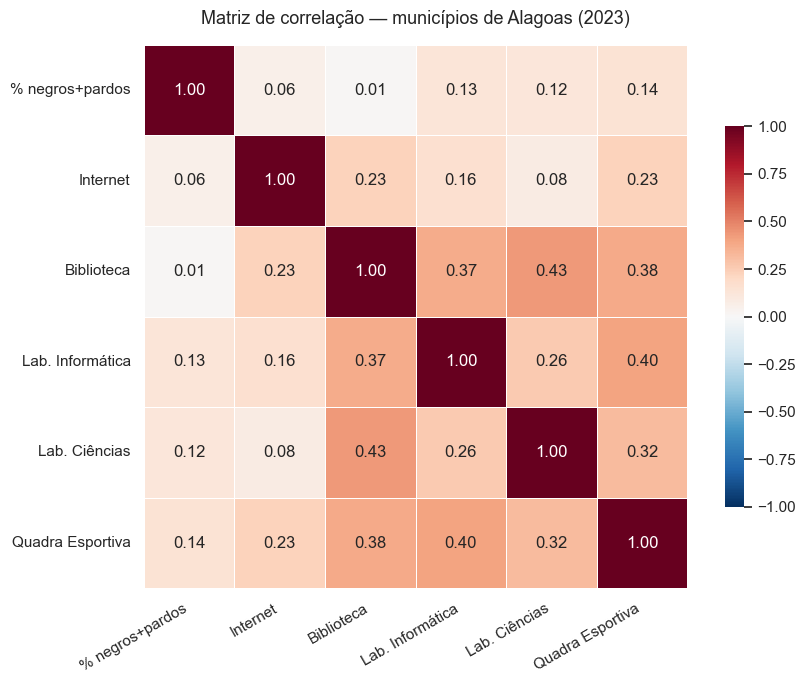


Correlação com % de alunos negros+pardos:
Biblioteca          0.012898
Internet            0.058547
Lab. Ciências       0.117931
Lab. Informática    0.130958
Quadra Esportiva    0.142522
Name: % negros+pardos, dtype: float64


In [2]:
#calcular por município em Alagoas
munic = al.groupby("NO_MUNICIPIO").agg(
    perc_negros          = ("PERC_NEGROS",               "mean"),
    perc_internet        = ("IN_INTERNET",               "mean"),
    perc_biblioteca      = ("IN_BIBLIOTECA",             "mean"),
    perc_lab_info        = ("IN_LABORATORIO_INFORMATICA","mean"),
    perc_lab_ciencias    = ("IN_LABORATORIO_CIENCIAS",   "mean"),
    perc_quadra          = ("IN_QUADRA_ESPORTES",        "mean"),
).dropna()

corr_cols = {
    "perc_negros":     "% negros+pardos",
    "perc_internet":   "Internet",
    "perc_biblioteca": "Biblioteca",
    "perc_lab_info":   "Lab. Informática",
    "perc_lab_ciencias":"Lab. Ciências",
    "perc_quadra":     "Quadra Esportiva",
}
corr_df = munic[list(corr_cols.keys())].rename(columns=corr_cols)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax, cbar_kws={"shrink": 0.7}
)
ax.set_title("Matriz de correlação — municípios de Alagoas (2023)", fontsize=13, pad=15)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/11_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCorrelação com % de alunos negros+pardos:")
print(corr_matrix["% negros+pardos"].drop("% negros+pardos").sort_values())

Regressão linear: negros x internet

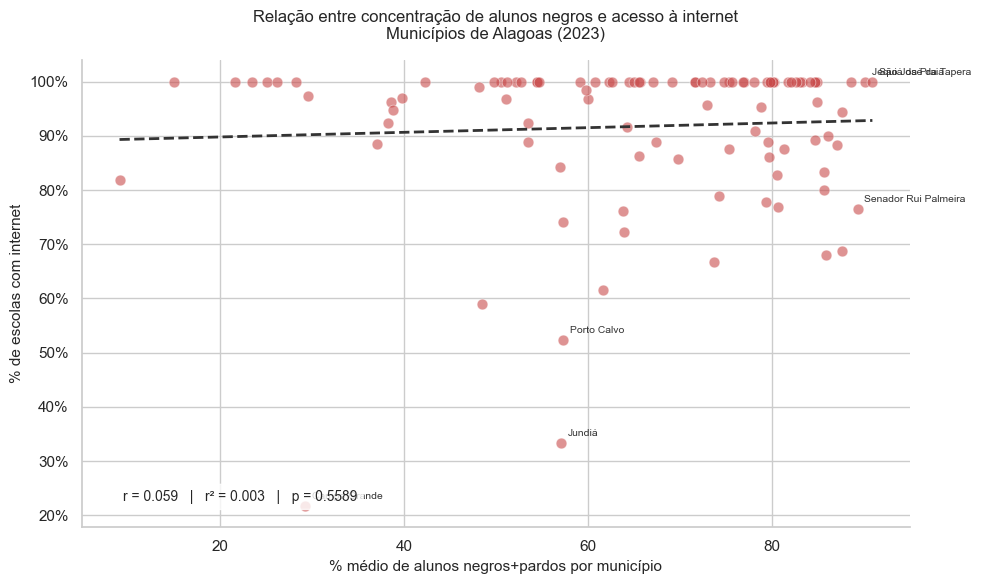


Inclinação: 0.0428
R²: 0.0034
p-valor: 0.558879
Interpretação: para cada 1% a mais de alunos negros+pardos,
o acesso à internet sobe 0.04 pontos percentuais.


In [3]:
x = munic["perc_negros"].values
y = munic["perc_internet"].values * 100

slope, intercept, r, p, se = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, alpha=0.6, color="#C94B4B", edgecolors="white", linewidth=0.5, s=60)

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="#333333", linewidth=2, linestyle="--")

top3 = munic.nlargest(3, "perc_negros")
bot3 = munic.nsmallest(3, "perc_internet")
for nome, row in pd.concat([top3, bot3]).iterrows():
    ax.annotate(nome,
                xy=(row["perc_negros"], row["perc_internet"]*100),
                xytext=(5, 5), textcoords="offset points",
                fontsize=7.5, color="#333333")

ax.set_xlabel("% médio de alunos negros+pardos por município", fontsize=11)
ax.set_ylabel("% de escolas com internet", fontsize=11)
ax.set_title("Relação entre concentração de alunos negros e acesso à internet\nMunicípios de Alagoas (2023)",
             fontsize=12, pad=15)

textstr = f"r = {r:.3f}   |   r² = {r**2:.3f}   |   p = {p:.4f}"
ax.text(0.05, 0.05, textstr, transform=ax.transAxes,
        fontsize=10, verticalalignment="bottom",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/12_regressao_negros_internet.png", dpi=150)
plt.show()

print(f"\nInclinação: {slope:.4f}")
print(f"R²: {r**2:.4f}")
print(f"p-valor: {p:.6f}")
print(f"Interpretação: para cada 1% a mais de alunos negros+pardos,")
print(f"o acesso à internet {'cai' if slope < 0 else 'sobe'} {abs(slope):.2f} pontos percentuais.")

Comparação Alagoas vs Brasil por rede de ensino

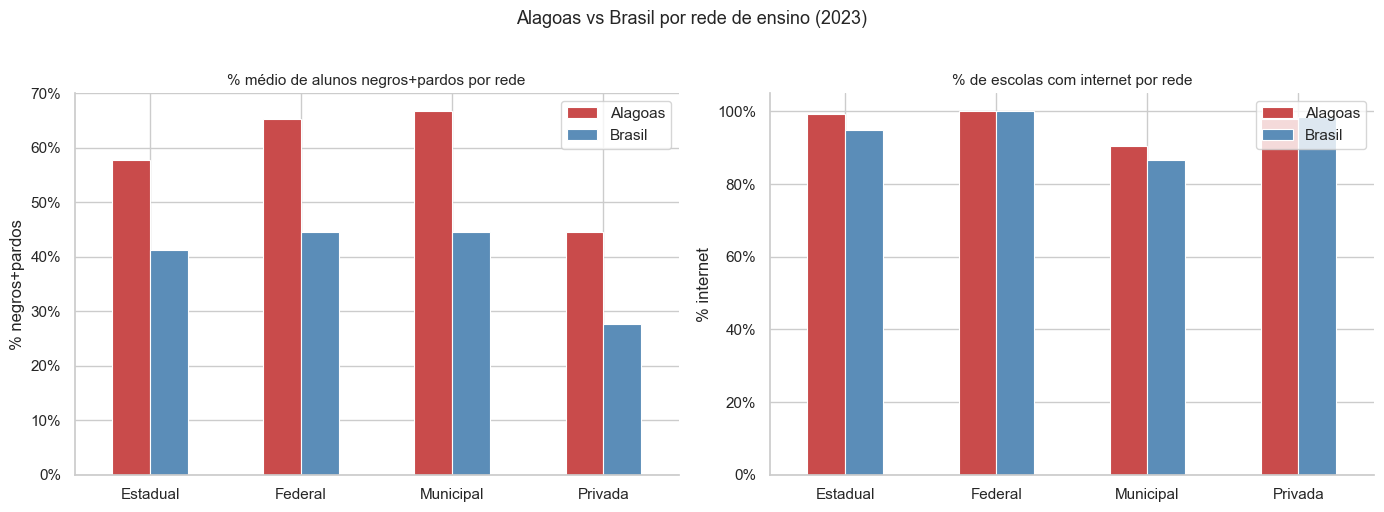

In [4]:
redes = ["Municipal", "Estadual", "Federal", "Privada"]

resumo = []
for fonte, nome in [(al, "Alagoas"), (df, "Brasil")]:
    for rede in redes:
        sub = fonte[fonte["REDE"] == rede]
        if len(sub) < 10:
            continue
        resumo.append({
            "Local": nome,
            "Rede": rede,
            "% negros+pardos": sub["PERC_NEGROS"].mean(),
            "% internet":      sub["IN_INTERNET"].mean() * 100,
        })

resumo_df = pd.DataFrame(resumo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, titulo in zip(
    axes,
    ["% negros+pardos", "% internet"],
    ["% médio de alunos negros+pardos por rede",
     "% de escolas com internet por rede"]
):
    pivot = resumo_df.pivot(index="Rede", columns="Local", values=col)
    pivot.plot(kind="bar", ax=ax, color=["#C94B4B","#5B8DB8"],
               edgecolor="white", linewidth=0.8)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel(col)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(title="")
    plt.setp(ax.get_xticklabels(), rotation=0)

sns.despine()
plt.suptitle("Alagoas vs Brasil por rede de ensino (2023)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/13_alagoas_vs_brasil_rede.png", dpi=150, bbox_inches="tight")
plt.show()

Resumo final

In [5]:
tabela = munic.copy()
tabela.columns = ["% negros+pardos", "% internet", "% biblioteca",
                  "% lab. informática", "% lab. ciências", "% quadra"]
tabela = tabela * 100
tabela = tabela.round(1)

print("=== Estatísticas descritivas — municípios de Alagoas ===\n")
print(tabela.describe().round(1).to_string())

tabela.reset_index().to_csv("../data/processed/tabela_municipios_final.csv", index=False)
print("\nTabela salva em data/processed/tabela_municipios_final.csv")

=== Estatísticas descritivas — municípios de Alagoas ===

       % negros+pardos  % internet  % biblioteca  % lab. informática  % lab. ciências  % quadra
count            102.0       102.0         102.0               102.0            102.0     102.0
mean            6559.1        91.7          20.3                17.1              8.9      20.1
std             1919.4        14.0          16.5                14.5              9.7      14.6
min              901.4        21.7           0.0                 0.0              0.0       0.0
25%             5449.3        88.3           7.7                 8.3              0.0      10.0
50%             7074.2       100.0          14.6                13.4              7.6      16.9
75%             8020.8       100.0          32.2                22.0             12.5      28.4
max             9097.0       100.0          71.4                77.8             50.0      69.7

Tabela salva em data/processed/tabela_municipios_final.csv
